<a href="https://colab.research.google.com/github/kagourrr/PSYC672/blob/main/Gour_PythonDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#This is the data from an ADR switch experiment.

The ADR data in this notebook consists of 7723 rows and 21 columns. Each row represents an indiviaual trial and each column represents a unique variable (i.e., data are in long format). These data were part of an experiment investigating the attention cost associated with a certain task-switch: from an attention switch, to a decision switch, or to a response switch. All of the data are organized into the following columns:
1) Trial = there are 300 task trials per participant
2) PID = numeric values used to protect participant's identities.
3) A_Cue_Order = Order of attention cue and decision cue was randomized.  1=attention-decision, 2=decision-attention
4) A_cue_code = Time a cue came on screen
5) D_cue_code = Time decision cue came on screen
6) Target_Code = Time target came on screen
7) Response = Correct responses (1-4), Incorrect responses (5-8)
8) CongruencyCode = Time for congruent code
9) ReactionTime = rows contain the trial-by-trial reaction times in milliseconds
10) SwitchType = The type of switch ranging from 1-8
11) TaskType = The type of task ranging from 1-8
12) AttentionSw = Could be a switch task or a stay
13) DecisionSw = Could be a switch task or a stay
14) ResponseSw = Could be a switch task or a stay
15) Letter/Number = If letter or number was shown
16) Color/Size = If color or letter was asked for
17) LeftRight/UpDown = The location of cue
18) Age = the age of the participant in years.
19) Gender = the participant's genetic sex (e.g., 1 = male/2 = female)
20) Handedness = the participant's dominant hand
21) ACC = rows contain the trial-by-trial accuracy (e.g., correct or incorrect)

#1) Let's get to know our data!

In [ ]:
# import modules
import pandas
import matplotlib
import matplotlib.pyplot as plt #more plotsss
import seaborn as sns #stats plot visualization!
import numpy as np
from scipy import stats

# magics command to generate plots inside notebook
#  a feature of IPython and Jupyter Notebooks that are essentially shortcuts designed to, control the behavior
#  of the interactive environment, and enable interactions with the operating system or other languages.
%matplotlib inline

# Set default plot size
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)


In [ ]:
MyData=pandas.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRu_Ead_l7Q-XD5knV0NwoaqCpf8DMEkm7fqIrDiktCdhEDjPPntQJufa5PcxmPPpjstGP6b2gQeDpA/pub?gid=0&single=true&output=csv")
#Load ADR Switch Data

In [ ]:
# You should, at the very least, know from the start how many rows/columns are in your data.
MyData.shape

(7723, 21)

In [ ]:
# The head() and tail() methods give you a sneak peak at the top and bottom few rows of the data respectively.
MyData.head()

,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,...,AttentionSw,DecisionSw,ResponseSw,Letter/Number,Color/Size,LeftRight/UpDown,Age,Gender,Handedness,ACC
0,1,3001,2,81,90,102,1,205,754.5,1.0,...,st,st,st,number,color,L/R,18,2,1,0.928
1,2,3001,1,53,90,111,6,207,1578.5,3.0,...,st,sw,sw,number,letter,U/D,18,2,1,0.928
2,3,3001,2,51,90,109,6,202,2103.0,1.0,...,st,st,st,number,letter,U/D,18,2,1,0.928
3,4,3001,2,37,90,107,1,202,926.5,7.0,...,sw,st,sw,letter,letter,U/D,18,2,1,0.928
4,5,3001,2,68,90,116,3,208,1278.0,8.0,...,sw,st,st,number,letter,L/R,18,2,1,0.928


In [ ]:
#    We could accomplish the same thing using the pandas.DataFrame.iloc method.
#    The iloc method allows us to retrieve rows and columns by position.
MyData.iloc[0:5,:]

,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,...,AttentionSw,DecisionSw,ResponseSw,Letter/Number,Color/Size,LeftRight/UpDown,Age,Gender,Handedness,ACC
0,1,3001,2,81,90,102,1,205,754.5,1.0,...,st,st,st,number,color,L/R,18,2,1,0.928
1,2,3001,1,53,90,111,6,207,1578.5,3.0,...,st,sw,sw,number,letter,U/D,18,2,1,0.928
2,3,3001,2,51,90,109,6,202,2103.0,1.0,...,st,st,st,number,letter,U/D,18,2,1,0.928
3,4,3001,2,37,90,107,1,202,926.5,7.0,...,sw,st,sw,letter,letter,U/D,18,2,1,0.928
4,5,3001,2,68,90,116,3,208,1278.0,8.0,...,sw,st,st,number,letter,L/R,18,2,1,0.928


In [ ]:
MyData.tail()

,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,...,AttentionSw,DecisionSw,ResponseSw,Letter/Number,Color/Size,LeftRight/UpDown,Age,Gender,Handedness,ACC
7718,296,3037,1,87,90,107,3,208,1362.5,7.0,...,sw,st,sw,number,color,L/R,18,2,1,0.93
7719,297,3037,1,72,90,110,2,204,1478.5,2.0,...,st,st,sw,number,color,U/D,18,2,1,0.93
7720,298,3037,2,46,90,114,4,205,1572.5,6.0,...,sw,sw,st,letter,letter,L/R,18,2,1,0.93
7721,299,3037,2,24,90,112,4,206,1952.5,4.0,...,st,sw,st,letter,color,U/D,18,2,1,0.93
7722,300,3037,1,44,90,104,2,205,1896.5,4.0,...,st,sw,st,letter,letter,L/R,18,2,1,0.93


In [ ]:
# Note that the describe() method displays only the continuous variables by default.
MyData.describe()

,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,TaskType,Age,Gender,Handedness,ACC
count,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000
mean,149.440243,3017.139713,1.505244,49.972550,90.009841,108.397514,2.833873,204.503431,1103.128059,4.464327,4.515214,19.482714,1.690146,1.106047,0.917186
std,86.359967,10.760900,0.500005,24.133038,1.968190,4.710220,1.565618,2.583810,578.724386,2.295930,2.304095,1.867276,0.462463,0.307918,0.080269
min,1.000000,3001.000000,1.000000,11.000000,32.000000,21.000000,1.000000,101.000000,55.000000,1.000000,1.000000,18.000000,1.000000,1.000000,0.643000
25%,75.000000,3007.000000,1.000000,31.000000,90.000000,104.000000,2.000000,203.000000,698.500000,2.000000,3.000000,18.000000,1.000000,1.000000,0.907000
50%,149.000000,3017.000000,2.000000,51.000000,90.000000,108.000000,3.000000,205.000000,940.500000,4.000000,5.000000,19.000000,2.000000,1.000000,0.937000
75%,223.000000,3027.000000,2.000000,71.000000,90.000000,112.000000,4.000000,207.000000,1334.750000,6.000000,7.000000,21.000000,2.000000,1.000000,0.963000
max,311.000000,3037.000000,2.000000,255.000000,251.000000,116.000000,8.000000,208.000000,3996.500000,8.000000,8.000000,25.000000,2.000000,2.000000,0.980000


In [ ]:
#  You can force the describe() method to display all columns using the include='all' argument
MyData.describe(include='all')

,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,...,AttentionSw,DecisionSw,ResponseSw,Letter/Number,Color/Size,LeftRight/UpDown,Age,Gender,Handedness,ACC
count,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,7723.000000,...,7723,7723,7723,7723,7723,7723,7723.000000,7723.000000,7723.000000,7723.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,st,st,st,number,color,U/D,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3924,3867,3884,3868,3912,3863,NaN,NaN,NaN,NaN
mean,149.440243,3017.139713,1.505244,49.972550,90.009841,108.397514,2.833873,204.503431,1103.128059,4.464327,...,NaN,NaN,NaN,NaN,NaN,NaN,19.482714,1.690146,1.106047,0.917186
std,86.359967,10.760900,0.500005,24.133038,1.968190,4.710220,1.565618,2.583810,578.724386,2.295930,...,NaN,NaN,NaN,NaN,NaN,NaN,1.867276,0.462463,0.307918,0.080269
min,1.000000,3001.000000,1.000000,11.000000,32.000000,21.000000,1.000000,101.000000,55.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,1.000000,1.000000,0.643000
25%,75.000000,3007.000000,1.000000,31.000000,90.000000,104.000000,2.000000,203.000000,698.500000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,1.000000,1.000000,0.907000
50%,149.000000,3017.000000,2.000000,51.000000,90.000000,108.000000,3.000000,205.000000,940.500000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,2.000000,1.000000,0.937000
75%,223.000000,3027.000000,2.000000,71.000000,90.000000,112.000000,4.000000,207.000000,1334.750000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,21.000000,2.000000,1.000000,0.963000


In [ ]:
MyData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7723 entries, 0 to 7722
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trial             7723 non-null   int64  
 1   PID               7723 non-null   int64  
 2   A_Cue_order       7723 non-null   int64  
 3   A_cue_code        7723 non-null   int64  
 4   D_cue_code        7723 non-null   int64  
 5   Target_code       7723 non-null   int64  
 6   Response          7723 non-null   int64  
 7   CongruencyCode    7723 non-null   int64  
 8   ReactionTime      7723 non-null   float64
 9   SwitchType        7723 non-null   float64
 10  TaskType          7723 non-null   float64
 11  AttentionSw       7723 non-null   object 
 12  DecisionSw        7723 non-null   object 
 13  ResponseSw        7723 non-null   object 
 14  Letter/Number     7723 non-null   object 
 15  Color/Size        7723 non-null   object 
 16  LeftRight/UpDown  7723 non-null   object 


In [ ]:
#We should probably recode some values?


NOTES:
1. The PID is our continuous participant identifying number
2. Gender is being treated as a continuous variable
3. We have some NaN

In [ ]:
# Even though we used seemingly continuous values as our participant ID#s, we can coerce Python to label those values as
#    categorical by converting the 'Participant' column using the astype() function.
MyData['PID']=MyData['PID'].astype('object')
MyData['Gender']=MyData['Gender'].astype('object')
MyData['Handedness']=MyData['Handedness'].astype('object')

In [ ]:
#  First, let's check the column's dtype
MyData.dtypes

,0
Trial,int64
PID,object
A_Cue_order,int64
A_cue_code,int64
D_cue_code,int64
Target_code,int64
Response,int64
CongruencyCode,int64
ReactionTime,float64
SwitchType,float64


In [ ]:
# Because you know a little bit of coding now, you can also put some of your inspection methods into a loop
for col in MyData.columns:
    print(f"Unique values in column '{col}':")
    print(MyData[col].unique())
    print()  # Blank line for readability

Unique values in column 'Trial':
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 2

#It seems like someone has an ACC of 0.64 ... this could be an outlier

#2) Now we must assess if there are outliers in ACC. We will do this by calculating if there are people who got less than 70% Acc score

In [ ]:
#It's time to assess who really tried at the task (>70% Acc) and who didn't...

ACCsummary=MyData.groupby(['PID','SwitchType']).ACC.mean()
ACCsummary = ACCsummary.reset_index()
#ACCsummary4plot=MyData.groupby(['Group','SwitchType']).TargetACC.mean()
display(ACCsummary.head(250))

,PID,SwitchType,ACC
0,3001,1.0,0.928
1,3001,2.0,0.928
2,3001,3.0,0.928
3,3001,4.0,0.928
4,3001,5.0,0.928
...,...,...,...
203,3037,4.0,0.930
204,3037,5.0,0.930
205,3037,6.0,0.930
206,3037,7.0,0.930


In [ ]:
# compute mean accuracy per participant
pid_acc = MyData.groupby("PID")["ACC"].mean().reset_index()

# find participants who scored at least 70%
good_pids = pid_acc[pid_acc["ACC"] >= 0.70]["PID"]

print(f"Number of participants kept: {len(good_pids)}")
print(f"Number of participants removed: {MyData['PID'].nunique() - len(good_pids)}")

# filter main dataset
MyData_clean = MyData[MyData["PID"].isin(good_pids)]

display(MyData_clean.head())


Number of participants kept: 24
Number of participants removed: 2


,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,...,AttentionSw,DecisionSw,ResponseSw,Letter/Number,Color/Size,LeftRight/UpDown,Age,Gender,Handedness,ACC
0,1,3001,2,81,90,102,1,205,754.5,1.0,...,st,st,st,number,color,L/R,18,2,1,0.928
1,2,3001,1,53,90,111,6,207,1578.5,3.0,...,st,sw,sw,number,letter,U/D,18,2,1,0.928
2,3,3001,2,51,90,109,6,202,2103.0,1.0,...,st,st,st,number,letter,U/D,18,2,1,0.928
3,4,3001,2,37,90,107,1,202,926.5,7.0,...,sw,st,sw,letter,letter,U/D,18,2,1,0.928
4,5,3001,2,68,90,116,3,208,1278.0,8.0,...,sw,st,st,number,letter,L/R,18,2,1,0.928


#We removed 2 participants who had an ACC score that was less than 70%. Now we will remove incorrect trials from the following statistical analyses!

In [ ]:
# Keep only trials with Response <= 4 (correct trials)
MyData_correct = MyData_clean[MyData_clean["Response"] <= 4]

print(f"Original number of trials: {len(MyData_clean)}")
print(f"Number of correct trials kept: {len(MyData_correct)}")
print(f"Number of incorrect trials removed: {len(MyData_clean) - len(MyData_correct)}")

display(MyData_correct.head())


Original number of trials: 7123
Number of correct trials kept: 6712
Number of incorrect trials removed: 411


,Trial,PID,A_Cue_order,A_cue_code,D_cue_code,Target_code,Response,CongruencyCode,ReactionTime,SwitchType,...,AttentionSw,DecisionSw,ResponseSw,Letter/Number,Color/Size,LeftRight/UpDown,Age,Gender,Handedness,ACC
0,1,3001,2,81,90,102,1,205,754.5,1.0,...,st,st,st,number,color,L/R,18,2,1,0.928
3,4,3001,2,37,90,107,1,202,926.5,7.0,...,sw,st,sw,letter,letter,U/D,18,2,1,0.928
4,5,3001,2,68,90,116,3,208,1278.0,8.0,...,sw,st,st,number,letter,L/R,18,2,1,0.928
5,6,3001,2,84,90,104,1,203,790.0,4.0,...,st,sw,st,number,color,L/R,18,2,1,0.928
7,8,3001,2,21,90,101,4,201,1546.5,1.0,...,st,st,st,letter,color,U/D,18,2,1,0.928


#Because incorrect trials have a response code >4, we filtered out those trials who have a response code >4 and we will assess our hypotheses that there is a 3 way interaction btwn ASW, DSW, and RSW! The number of trials removed is printed above.

#Now we can visualize the data!

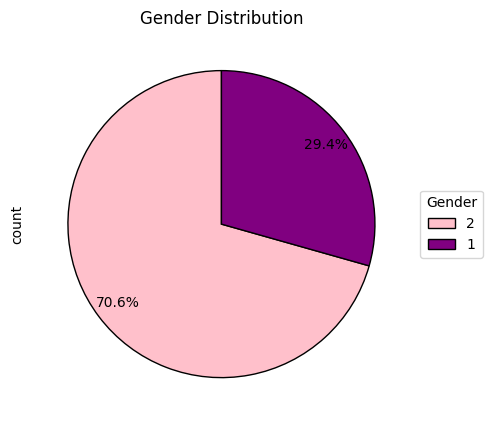

In [ ]:
# 2 = Women, 1 = Men

# Define colors (customize as you like)
colors = ['pink','purple']

plt.figure()
MyData_clean.Gender.value_counts().plot.pie(figsize=(5,5),
  autopct='%1.1f%%',  # Show percentages with one decimal
  startangle=90,       # Rotate start angle for better layout
  colors=colors,
  pctdistance=0.85,    # Position percentage labels nicely
  labels=None,         # Hide default labels to customize legend
  wedgeprops={'edgecolor':'black'}  # Add black edges for wedges
)
plt.title('Gender Distribution')
# Add legend with labels
plt.legend(MyData_clean.Gender.value_counts().index, title='Gender', loc='center left', bbox_to_anchor=(1, 0, .5, 1))
plt.tight_layout()


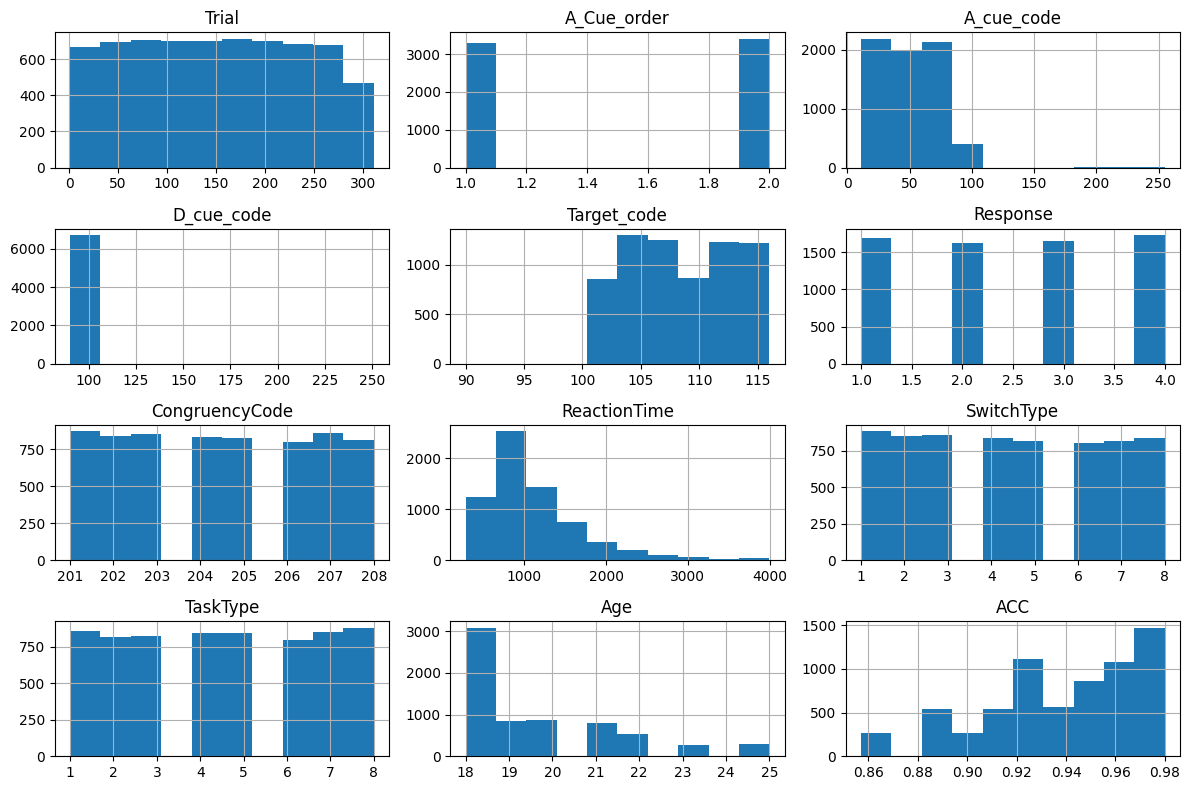

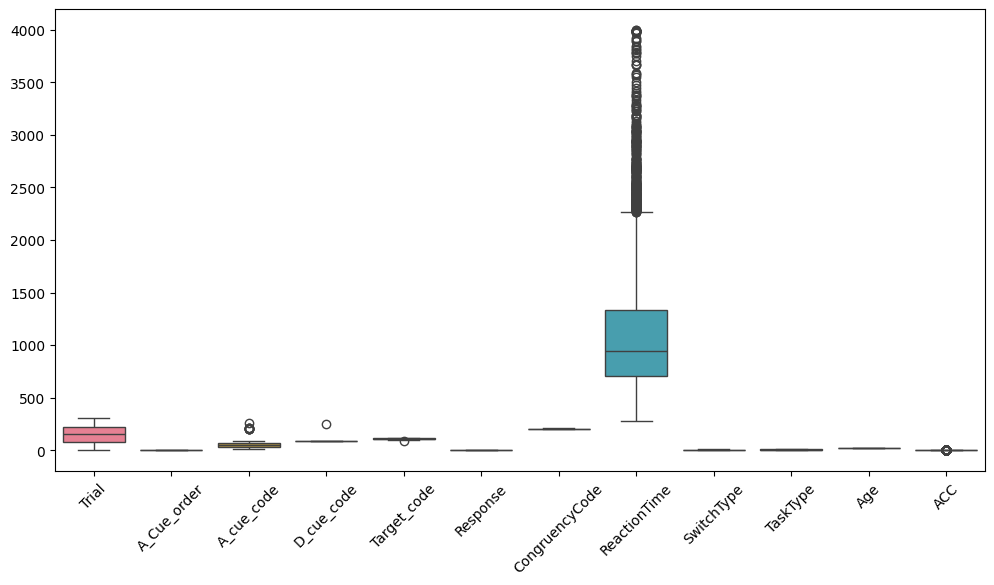

In [ ]:
#Now for plots and visualizations!

MyData_correct.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=MyData_correct.select_dtypes(include=[np.number]))
plt.xticks(rotation=45)
plt.show()


## 3) Analyze Clean Data
We will now perform several analyses:
1. Correlation
2. Regression
3. Chi-squared
4. t-test
5. ANOVA  
We’ll also use `groupby()` and `pivot_table()` for at least two of these.


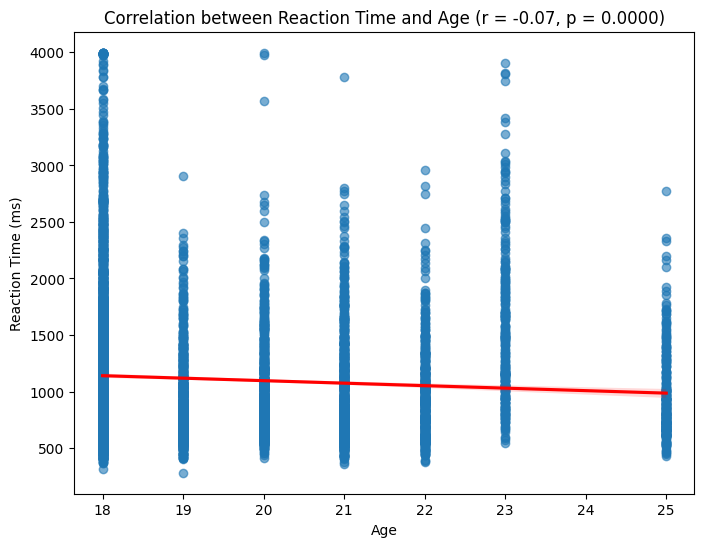

In [ ]:
from scipy.stats import pearsonr

rt_age = MyData_correct[["ReactionTime", "Age"]].dropna()

# Correlation
r, p = pearsonr(rt_age["ReactionTime"], rt_age["Age"])

# Scatterplot
plt.figure(figsize=(8,6))
sns.regplot(x="Age", y="ReactionTime", data=rt_age, ci=95, scatter_kws={'alpha':0.6}, line_kws={"color":"red"})
plt.title(f"Correlation between Reaction Time and Age (r = {r:.2f}, p = {p:.4f})")
plt.xlabel("Age")
plt.ylabel("Reaction Time (ms)")
plt.show()


#It seems that there is a signficant, negative association between reaction time and age.

In [ ]:
import statsmodels.formula.api as smf

df = MyData_correct[["ReactionTime", "Age", "SwitchType"]].dropna()

# regression
model = smf.ols("ReactionTime ~ Age + C(SwitchType)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           ReactionTime   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     20.83
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           1.68e-31
Time:                        14:02:10   Log-Likelihood:                -52011.
No. Observations:                6712   AIC:                         1.040e+05
Df Residuals:                    6703   BIC:                         1.041e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1424.3890 

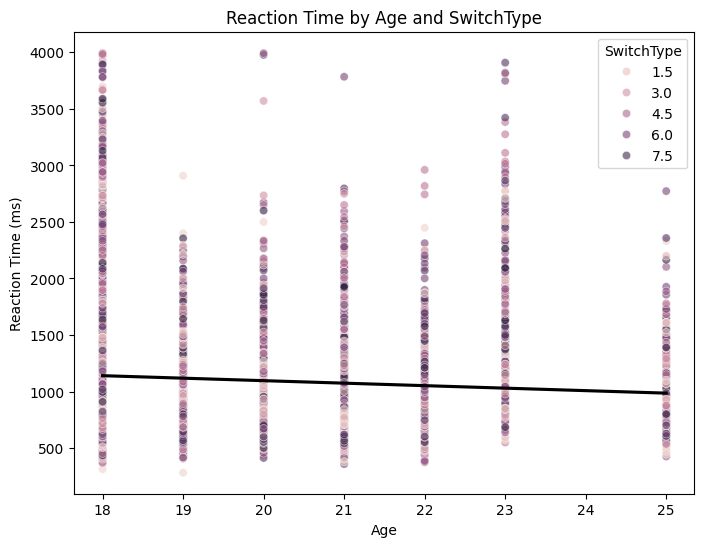

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Age", y="ReactionTime", hue="SwitchType", data=df, alpha=0.6)
sns.regplot(x="Age", y="ReactionTime", data=df, scatter=False, ci=None, color="black")
plt.title("Reaction Time by Age and SwitchType")
plt.xlabel("Age")
plt.ylabel("Reaction Time (ms)")
plt.show()

#We can also see that age and switch type can predict reaction time. It seems like the R^2 is a bit small, so switch type and age do not account for a majority of the variance in reaction time. However, there is still a signficant, predictive relationship between them.

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Chi Square assessing association between Handedness and Gender
table = pd.crosstab(MyData_correct["Handedness"], MyData_correct["Gender"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-squared Test on Handedness and Gender")
print("Chi2:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)
print("\nExpected frequencies:\n", expected)

Chi-squared Test on Handedness and Gender
Chi2: 222.91061675855659
Degrees of freedom: 1
p-value: 2.0966327672224902e-50

Expected frequencies:
 [[1823.24791418 4388.75208582]
 [ 146.75208582  353.24791418]]


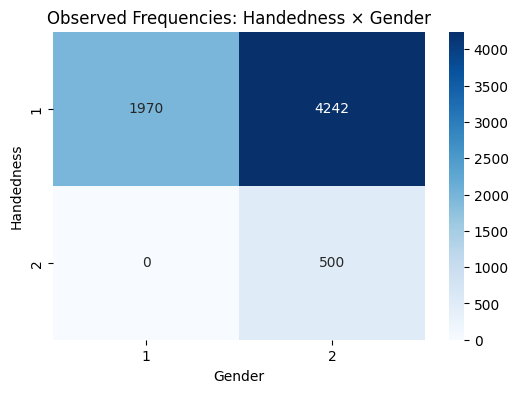

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(table, annot=True, fmt="d", cmap="Blues")
plt.title("Observed Frequencies: Handedness × Gender")
plt.ylabel("Handedness")
plt.xlabel("Gender")
plt.show()

#There is a significant association between Handedness and Gender

In [ ]:
# Groupby mean RT by gender
rt_by_gender = MyData_correct.groupby("Gender")["ReactionTime"].mean()
print(rt_by_gender)

Gender
1    1119.047970
2    1099.791544
Name: ReactionTime, dtype: float64


Now let's assess if these group means are significantly different using our t-test!

In [ ]:
from scipy.stats import ttest_ind

df = MyData_correct.dropna(subset=["ReactionTime", "Gender"])

# Split by gender (coded as 1 = Male, 2 = Female)
male_rt = df[df["Gender"] == 1]["ReactionTime"]
female_rt = df[df["Gender"] == 2]["ReactionTime"]

# Independent samples t-test (Welch's)
t_stat, p_val = ttest_ind(male_rt, female_rt, equal_var=False)

print("T-test: Reaction Time by Gender")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")
print(f"Male mean RT = {male_rt.mean():.2f}, Female mean RT = {female_rt.mean():.2f}")


T-test: Reaction Time by Gender
t-statistic = 1.188, p-value = 0.2350
Male mean RT = 1119.05, Female mean RT = 1099.79


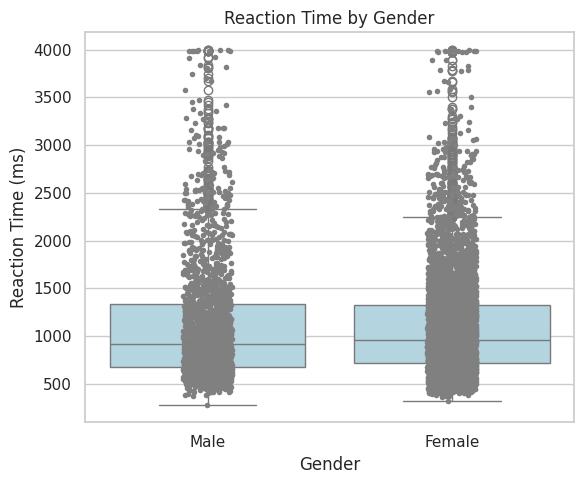

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 5))

# Boxplot
sns.boxplot(x="Gender", y="ReactionTime", data=df, color="lightblue")

# Stripplot for individual points (less crowded than swarmplot)
sns.stripplot(x="Gender", y="ReactionTime", data=df, color="gray", size=4, jitter=True)

# Set custom labels for gender
plt.xticks([0, 1], ['Male', 'Female'])

plt.title("Reaction Time by Gender")
plt.ylabel("Reaction Time (ms)")
plt.xlabel("Gender")

plt.tight_layout()
plt.show()


#It seems like men and women do not significantly differ on reaction time.

In [ ]:
# Pivot table with 3 way interaction
pivot_rt = MyData_correct.pivot_table(
    values="ReactionTime",
    index=["AttentionSw", "DecisionSw", "ResponseSw"],
    aggfunc="mean"
)
print(pivot_rt.head(20))

                                   ReactionTime
AttentionSw DecisionSw ResponseSw              
st          st         st            990.772624
                       sw           1049.925882
            sw         st           1162.080952
                       sw           1152.650932
sw          st         st           1124.347670
                       sw           1063.645910
            sw         st           1254.120025
                       sw           1055.873171


Now we can assess the 3-way interaction's significance using an ANOVA!

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Drop rows with missing values in relevant columns
df_anova = MyData_correct.dropna(subset=["ReactionTime", "AttentionSw", "DecisionSw", "ResponseSw"])

# Make sure the factors are treated as categorical
df_anova["AttentionSw"] = df_anova["AttentionSw"].astype("category")
df_anova["DecisionSw"] = df_anova["DecisionSw"].astype("category")
df_anova["ResponseSw"] = df_anova["ResponseSw"].astype("category")

# Build the formula for three-way ANOVA
formula = 'ReactionTime ~ C(AttentionSw) * C(DecisionSw) * C(ResponseSw)'

# Fit the model
model = ols(formula, data=df_anova).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)  # Type II sums of squares
print(anova_table)


                                                  sum_sq      df          F  \
C(AttentionSw)                              2.174023e+06     1.0   6.855381   
C(DecisionSw)                               1.676079e+07     1.0  52.852067   
C(ResponseSw)                               4.203510e+06     1.0  13.254996   
C(AttentionSw):C(DecisionSw)                2.417081e+06     1.0   7.621819   
C(AttentionSw):C(ResponseSw)                9.940660e+06     1.0  31.346042   
C(DecisionSw):C(ResponseSw)                 4.387751e+06     1.0  13.835964   
C(AttentionSw):C(DecisionSw):C(ResponseSw)  4.983630e+05     1.0   1.571496   
Residual                                    2.126016e+09  6704.0        NaN   

                                                  PR(>F)  
C(AttentionSw)                              8.857346e-03  
C(DecisionSw)                               4.004626e-13  
C(ResponseSw)                               2.739032e-04  
C(AttentionSw):C(DecisionSw)                5.782310

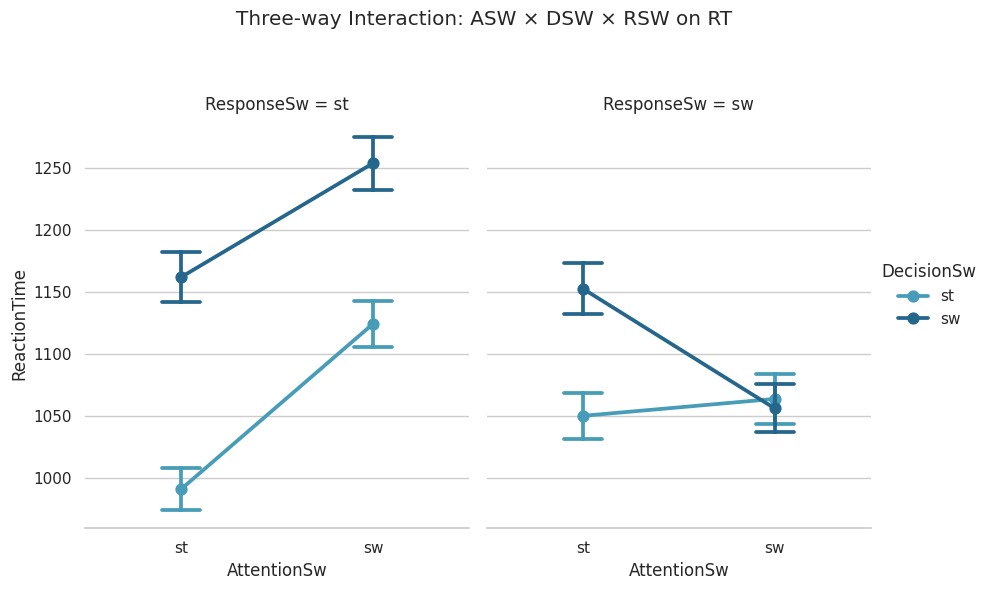

In [ ]:
#https://seaborn.pydata.org/examples/pointplot_anova.html but not sure if this is best way to plot 3-way interaction in python?
sns.set_theme(style="whitegrid")

# RT as a function of ASW, DSW, and RSW
g = sns.catplot(
    data=df_anova,
    x="AttentionSw",
    y="ReactionTime",
    hue="DecisionSw",
    col="ResponseSw",
    capsize=.2, palette="YlGnBu_d", errorbar="se",
    kind="point", height=6, aspect=.75,
)
g.despine(left=True)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Three-way Interaction: ASW × DSW × RSW on RT")
plt.show()

#This is the most important result. It seems like there is NOT a significant interaction between ASW x DSW x RSW on reaction time (F = 1.57, p = 0.21).